# 6.1 Sentiment Distribution by Brand

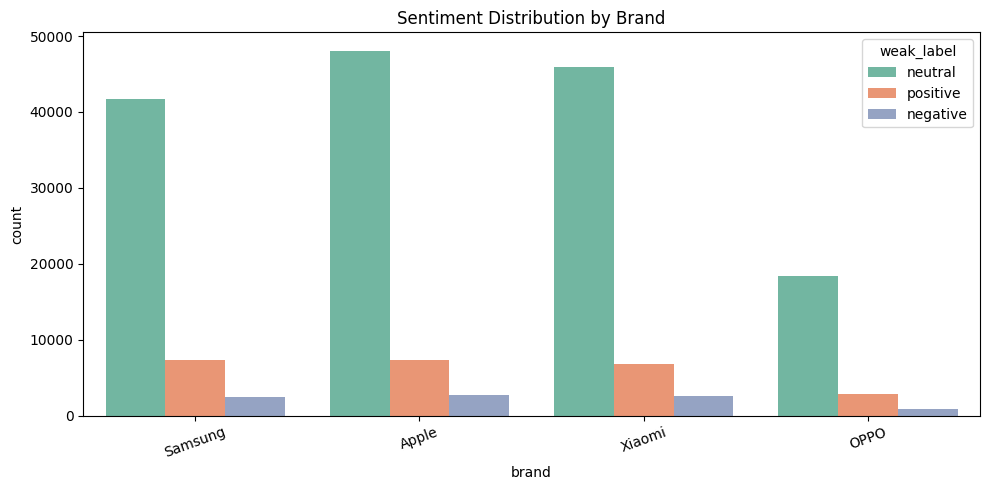

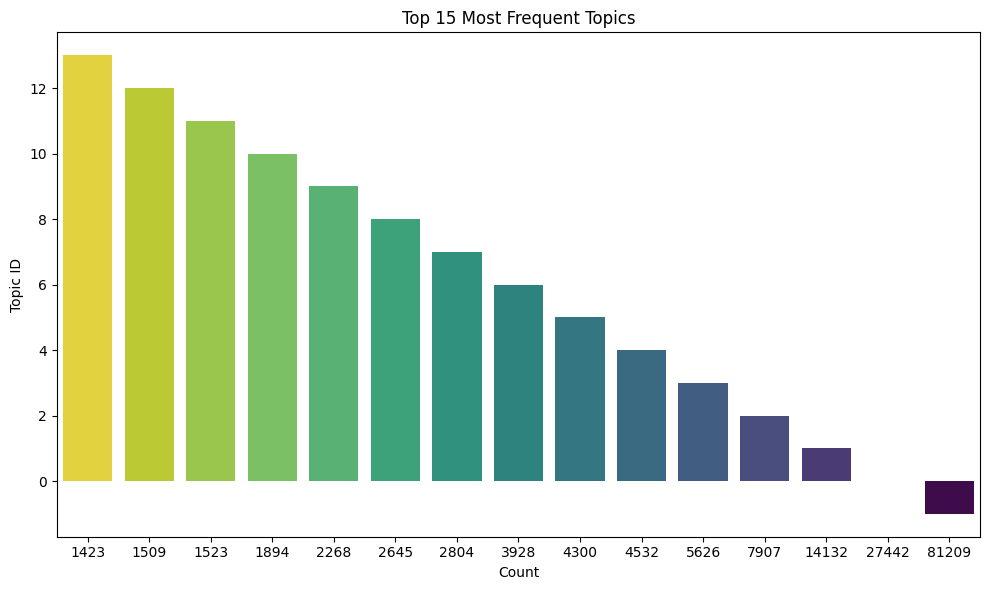

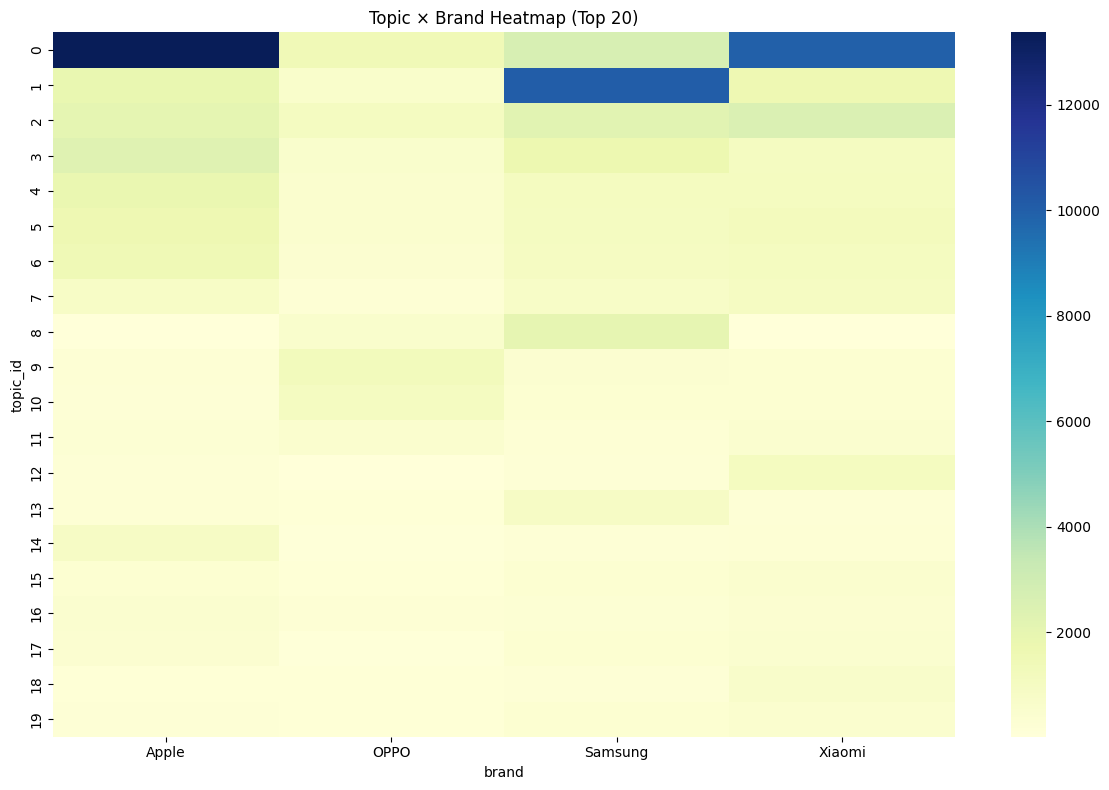

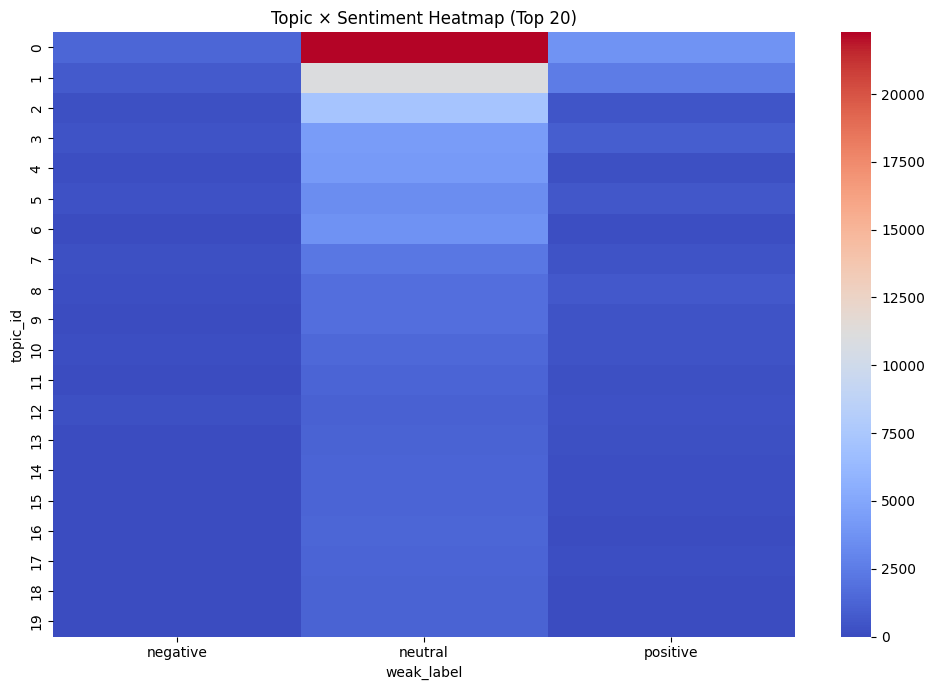

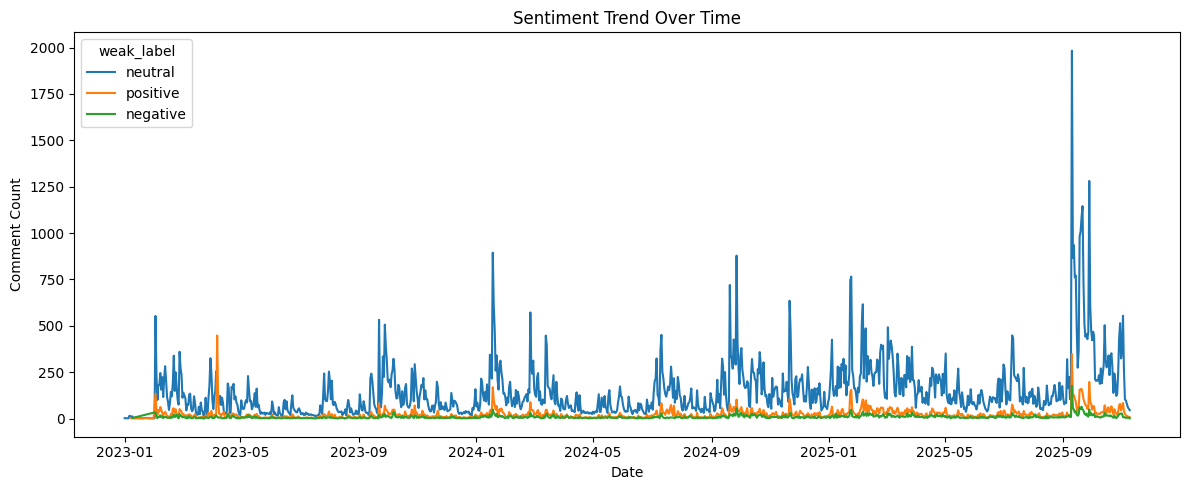

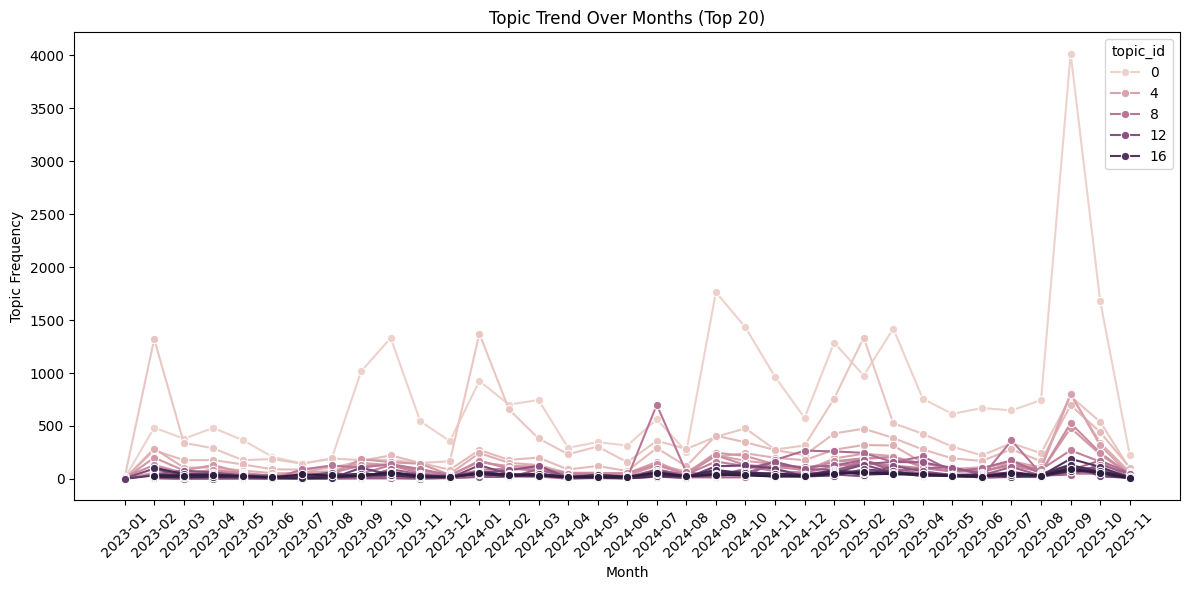

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("analysis_master.csv")


# =========================================
# 6.1 Sentiment × Brand
# =========================================
plt.figure(figsize=(10,5))
sns.countplot(data=df, x="brand", hue="weak_label", palette="Set2")
plt.title("Sentiment Distribution by Brand")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


# =========================================
# 6.2 TOP TOPICS
# =========================================
top_topics = df["topic_id"].value_counts().head(15)

plt.figure(figsize=(10,6))
sns.barplot(
    x=top_topics.values,
    y=top_topics.index,
    hue=top_topics.index,     
    palette="viridis",
    legend=False
)
plt.title("Top 15 Most Frequent Topics")
plt.xlabel("Count")
plt.ylabel("Topic ID")
plt.tight_layout()
plt.show()


# =========================================
# CHUẨN BỊ TOPIC TOP 20
# =========================================
top20 = df["topic_id"].value_counts().head(20).index
df_top = df[df["topic_id"].isin(top20)]


# =========================================
# 6.3 Topic × Brand Heatmap
# =========================================

# 1) Lọc bỏ topic -1
df_top = df[df["topic_id"] != -1]

# 2) Lấy top 20 topic nhiều nhất (OPTIONAL nhưng nên làm)
top20 = df_top["topic_id"].value_counts().head(20).index
df_top = df_top[df_top["topic_id"].isin(top20)]

# 3) Crosstab sau khi lọc
topic_brand = pd.crosstab(df_top["topic_id"], df_top["brand"])

plt.figure(figsize=(12,8))
sns.heatmap(topic_brand, cmap="YlGnBu")
plt.title("Topic × Brand Heatmap (Top 20)")
plt.tight_layout()
plt.show()


# =========================================
# 6.4 Topic × Sentiment Heatmap
# =========================================
topic_sent = pd.crosstab(df_top["topic_id"], df_top["weak_label"])

plt.figure(figsize=(10,7))
sns.heatmap(topic_sent, cmap="coolwarm")
plt.title("Topic × Sentiment Heatmap (Top 20)")
plt.tight_layout()
plt.show()


# =========================================
# 6.5 Sentiment Trend Over Time 
# =========================================

df["date_vn"] = pd.to_datetime(df["date_vn"], errors="coerce")

df_daily = (
    df.dropna(subset=["date_vn"])
      .groupby([df["date_vn"].dt.date, "weak_label"])
      .size()
      .reset_index(name="count")
)

plt.figure(figsize=(12,5))
sns.lineplot(data=df_daily, x="date_vn", y="count", hue="weak_label")
plt.title("Sentiment Trend Over Time")
plt.xlabel("Date")
plt.ylabel("Comment Count")
plt.tight_layout()
plt.show()


# =========================================
# 6.6 Topic Trend Over Months 
# =========================================

# CHUYỂN PERIOD -> STRING YYYY-MM
df["month_vn"] = pd.to_datetime(df["date_vn"], errors="coerce").dt.strftime("%Y-%m")

df_month_topic = (
    df[df["topic_id"].isin(top20)]
      .dropna(subset=["month_vn"])
      .groupby(["month_vn", "topic_id"])
      .size()
      .reset_index(name="count")
)

# SORT THEO THỜI GIAN
df_month_topic = df_month_topic.sort_values("month_vn")

plt.figure(figsize=(12,6))
sns.lineplot(
    data=df_month_topic,
    x="month_vn",
    y="count",
    hue="topic_id",
    marker="o"
)
plt.title("Topic Trend Over Months (Top 20)")
plt.xlabel("Month")
plt.ylabel("Topic Frequency")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()